# Koduppgift 10 - Kapitel 7: ANN på MNIST med KerasTuner

**Uppgift:**
a) Träna en ANN-modell på MNIST-datan. Vad får du för resultat?

b) Prova justera hyperparametrarna med KerasTuner. Får du bättre resultat?

# Importera Bibliotek

Importerar nödvändiga bibliotek för att arbeta med MNIST, bygga neurala nätverk och optimera hyperparametrar.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tempfile

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import keras_tuner as kt

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {keras.__version__}")

TensorFlow version: 3.11.3


# Sätt Random Seed för Reproducerbarhet

Sätter random seeds för att säkerställa att resultaten blir reproducerbara. Detta är viktigt för att kunna jämföra resultat mellan olika körningar.

In [20]:
# Sätt random seed för reproducerbarhet
# np.random.seed(42): Säkerställer att NumPy genererar samma slumptal varje gång
# keras.utils.set_random_seed(42): Säkerställer att TensorFlow/Keras använder samma initialisering
# Varför 42? Det är en konvention inom ML-communityn (från "Hitchhiker's Guide to the Galaxy")
np.random.seed(42)
keras.utils.set_random_seed(42)

print("Random seeds satta för reproducerbarhet!")

Random seeds satta för reproducerbarhet!


# Ladda och Förbereda Data

Laddar MNIST-datasetet, normaliserar pixlar till [0,1] och delar upp i träning, validering och test.

In [21]:
# Ladda MNIST-datasetet
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Träningsdata form: {X_train_full.shape}")
print(f"Testdata form: {X_test.shape}")

Träningsdata form: (60000, 28, 28)
Testdata form: (10000, 28, 28)


In [22]:
# Dela upp träningsdata i träning och validering
# Normalisera pixlar genom att dividera med 255.0 (pixlar är 0-255)
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

print(f"Träningsdata: {X_train.shape[0]} bilder")
print(f"Valideringsdata: {X_valid.shape[0]} bilder")
print(f"Testdata: {X_test.shape[0]} bilder")

Träningsdata: 55000 bilder
Valideringsdata: 5000 bilder
Testdata: 10000 bilder


# Visualisera Data

Visar några exempelbilder och klassfördelningen för att förstå datan.

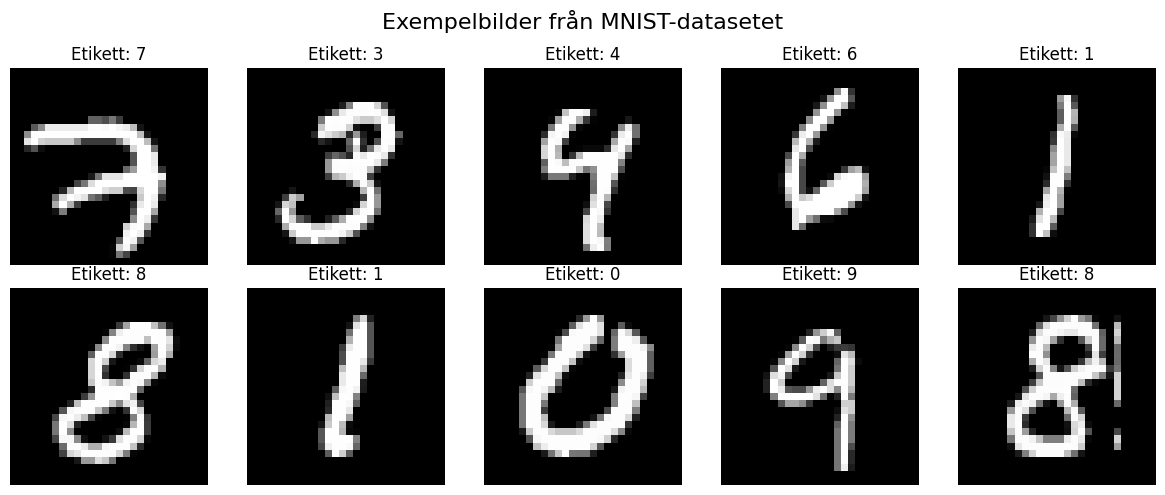

In [23]:
# Visualisera några exempelbilder
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Exempelbilder från MNIST-datasetet', fontsize=16)
for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(X_train[i], cmap='gray')
    axes[row, col].set_title(f'Etikett: {y_train[i]}', fontsize=12)
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

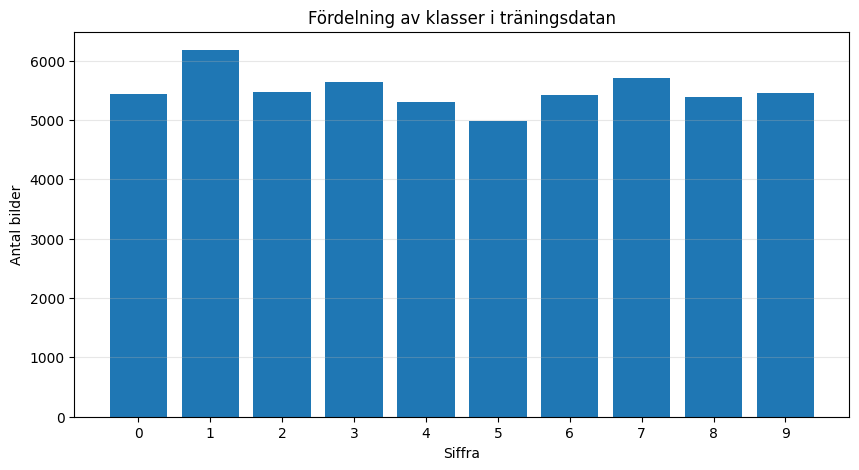

In [24]:
# Visa fördelning av klasser
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts)
plt.xlabel('Siffra')
plt.ylabel('Antal bilder')
plt.title('Fördelning av klasser i träningsdatan')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Del A: Bygg och Träna ANN-modell

Bygger en neural nätverksmodell med manuellt valda hyperparametrar för att klassificera MNIST-siffror.

In [25]:
# Bygg modell med Sequential API
model = Sequential([
    Input(shape=[28, 28]),  # Definierar input-shape (28x28 bilder)
    Flatten(),  # Konverterar 28x28 bilder till 784 features
    Dense(128, activation='relu'),  # Hidden layer 1: 128 neuroner med ReLU
    Dropout(0.3),  # Regularisering: stänger av 30% av neuronerna slumpmässigt
    Dense(64, activation='relu'),  # Hidden layer 2: 64 neuroner
    Dropout(0.3),  # Ytterligare regularisering
    Dense(10, activation='softmax')  # Output layer: 10 klasser (siffror 0-9)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Kompilera modellen
# Adam: adaptiv optimizer som justerar learning rate automatiskt
# SparseCategoricalCrossentropy: används när labels är heltal (0-9)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
# Early stopping: stoppar träningen om val_loss inte förbättras
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Vänta 5 epoker innan stopp
    restore_best_weights=True  # Återställ till bästa vikter
)

# Träna modellen
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8392 - loss: 0.5290 - val_accuracy: 0.9464 - val_loss: 0.1807
Epoch 2/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9279 - loss: 0.2452 - val_accuracy: 0.9622 - val_loss: 0.1329
Epoch 3/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9448 - loss: 0.1908 - val_accuracy: 0.9684 - val_loss: 0.1131
Epoch 4/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9527 - loss: 0.1599 - val_accuracy: 0.9688 - val_loss: 0.1081
Epoch 5/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9581 - loss: 0.1423 - val_accuracy: 0.9718 - val_loss: 0.0957
Epoch 6/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9623 - loss: 0.1240 - val_accuracy: 0.9742 - val_loss: 0.0931
Epoch 7/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9648 - loss: 0.1162 - val_accuracy: 0.9752 - val_loss: 0.0884
Epoch 8/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9665 - loss: 0.1088 - val_accuracy: 0.

# Utvärdera Manuellt Tränad Modell

Utvärderar modellen på testdatan för att se hur bra den presterar.

In [28]:
# Utvärdera på testdata
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("RESULTAT - Manuellt Tränad Modell")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 60)

RESULTAT - Manuellt Tränad Modell
Test Loss: 0.0748
Test Accuracy: 0.9794 (97.94%)


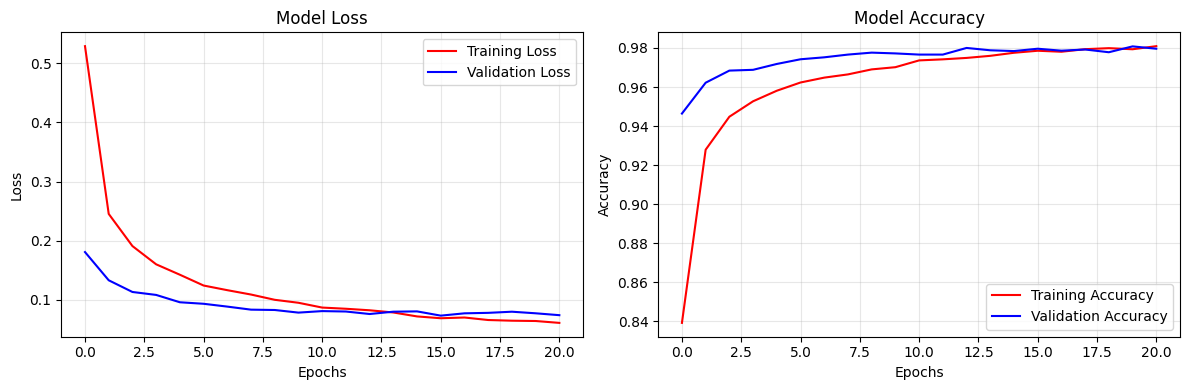

In [29]:
# Visualisera träningshistorik
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'r', label='Training Loss')
plt.plot(history.history['val_loss'], 'b', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'r', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], 'b', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Gör prediktioner och visa classification report
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)  # Konvertera sannolikheter till klasser

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Del B: Optimera Hyperparametrar med KerasTuner

Använder KerasTuner för att automatiskt hitta bästa hyperparametrarna. Vi optimerar antal neuroner i hidden layers, dropout rate och learning rate.

In [31]:
# Definiera funktion som bygger modell med hyperparametrar från tuner
def build_model(hp):
    model = Sequential([
        Input(shape=[28, 28]),  # Definierar input-shape (28x28 bilder)
        Flatten(),  # Konverterar 28x28 bilder till 784 features
        # Antal neuroner i första hidden layer väljs av tuner (64-256)
        Dense(units=hp.Int('units_1', min_value=64, max_value=256, step=64), activation='relu'),
        # Dropout rate väljs av tuner (0.2-0.4)
        Dropout(rate=hp.Float('dropout_1', min_value=0.2, max_value=0.4, step=0.1)),
        # Antal neuroner i andra hidden layer (32-128)
        Dense(units=hp.Int('units_2', min_value=32, max_value=128, step=32), activation='relu'),
        Dropout(rate=hp.Float('dropout_2', min_value=0.2, max_value=0.4, step=0.1)),
        Dense(10, activation='softmax')  # Output layer: 10 klasser
    ])
    
    # Learning rate väljs av tuner
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("Model builder-funktion definierad!")

Model builder-funktion definierad!


In [32]:
# Skapa RandomSearch tuner
# Använd tempfile för att undvika problem med svenska tecken i sökvägar
tuner_dir = os.path.join(tempfile.gettempdir(), 'keras_tuner_mnist')
os.makedirs(tuner_dir, exist_ok=True)

max_trials = 10  # Antal modellkonfigurationer att testa

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',  # Maximera validation accuracy
    max_trials=max_trials,
    executions_per_trial=1,
    directory=tuner_dir,
    project_name='mnist_ann_optimization',
    overwrite=True
)

print(f"KerasTuner skapad! Kommer testa {max_trials} olika konfigurationer.")

KerasTuner skapad! Kommer testa 10 olika konfigurationer.


In [33]:
# Kör hyperparametersökningen
print("Börjar söka efter bästa hyperparametrar...")
print("Detta kan ta en stund beroende på din hårdvara.\n")

tuner.search(
    X_train, y_train,
    epochs=20,  # Färre epoker per modell för snabbare sökning
    batch_size=128,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

print("\nHyperparametersökning klar!")

Trial 10 Complete [00h 01m 15s]
val_accuracy: 0.9718000292778015

Best val_accuracy So Far: 0.9750000238418579
Total elapsed time: 00h 09m 05s

Hyperparametersökning klar!


In [34]:
# Hämta bästa modellen och dess hyperparametrar
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 60)
print("BÄSTA HYPERPARAMETRARNA")
print("=" * 60)
print(f"Units i första hidden layer: {best_hyperparameters.get('units_1')}")
print(f"Units i andra hidden layer: {best_hyperparameters.get('units_2')}")
print(f"Dropout rate 1: {best_hyperparameters.get('dropout_1')}")
print(f"Dropout rate 2: {best_hyperparameters.get('dropout_2')}")
print(f"Learning rate: {best_hyperparameters.get('learning_rate')}")
print("=" * 60)

BÄSTA HYPERPARAMETRARNA
Units i första hidden layer: 128
Units i andra hidden layer: 32
Dropout rate 1: 0.30000000000000004
Dropout rate 2: 0.4
Learning rate: 0.001


C:\Users\daedi\AppData\Roaming\Python\Python311\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Träna Bästa Modellen på Hela Träningsdatan

Tränar modellen med bästa hyperparametrarna på hela träningsdatan (inklusive valideringsdata) för bästa resultat.

In [35]:
# Kombinera träning och valideringsdata
X_train_full_combined = np.concatenate([X_train, X_valid], axis=0)
y_train_full_combined = np.concatenate([y_train, y_valid], axis=0)

# Bygg modell med bästa hyperparametrarna
model_optimized = build_model(best_hyperparameters)

# Träna på hela träningsdatan
history_optimized = model_optimized.fit(
    X_train_full_combined, y_train_full_combined,
    epochs=30,
    batch_size=128,
    validation_split=0.1,  # Använd 10% för validering
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

print("\nTräning klar!")

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7784 - loss: 0.7164 - val_accuracy: 0.9435 - val_loss: 0.2129
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9031 - loss: 0.3425 - val_accuracy: 0.9580 - val_loss: 0.1556
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9231 - loss: 0.2731 - val_accuracy: 0.9642 - val_loss: 0.1301
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9354 - loss: 0.2330 - val_accuracy: 0.9670 - val_loss: 0.1153
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9429 - loss: 0.2069 - val_accuracy: 0.9748 - val_loss: 0.1013
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9475 - loss: 0.1894 - val_accuracy: 0.9752 - val_loss: 0.0980
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9511 - loss: 0.1751 - val_accuracy: 0.9735 - val_loss: 0.0952
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9541 - loss: 0.1621 - val_accuracy: 0.

# Utvärdera Optimerad Modell

Utvärderar den optimerade modellen på testdatan och jämför med den manuellt tränade modellen.

In [36]:
# Utvärdera optimerad modell
test_loss_opt, test_accuracy_opt = model_optimized.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("RESULTAT - Optimerad Modell (KerasTuner)")
print("=" * 60)
print(f"Test Loss: {test_loss_opt:.4f}")
print(f"Test Accuracy: {test_accuracy_opt:.4f} ({test_accuracy_opt*100:.2f}%)")
print("=" * 60)

RESULTAT - Optimerad Modell (KerasTuner)
Test Loss: 0.0923
Test Accuracy: 0.9756 (97.56%)


In [37]:
# Jämför de två modellerna
print("=" * 60)
print("JÄMFÖRELSE MELLAN MODELLERNA")
print("=" * 60)
print(f"\nManuellt Tränad Modell:")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")
print(f"\nOptimerad Modell (KerasTuner):")
print(f"  Test Accuracy: {test_accuracy_opt:.4f} ({test_accuracy_opt*100:.2f}%)")
print(f"  Test Loss: {test_loss_opt:.4f}")

improvement = test_accuracy_opt - test_accuracy
print(f"\nFörbättring: {improvement:.4f} ({improvement*100:.2f} procentenheter)")

if improvement > 0:
    print("\nKerasTuner förbättrade modellen!")
elif improvement < 0:
    print("\nManuell modell presterade bättre.")
else:
    print("\nModellerna presterade lika bra.")

print("=" * 60)

JÄMFÖRELSE MELLAN MODELLERNA

Manuellt Tränad Modell:
  Test Accuracy: 0.9794 (97.94%)
  Test Loss: 0.0748

Optimerad Modell (KerasTuner):
  Test Accuracy: 0.9756 (97.56%)
  Test Loss: 0.0923

Förbättring: -0.0038 (-0.38 procentenheter)

Manuell modell presterade bättre.


In [38]:
# Classification report för optimerad modell
y_pred_opt_proba = model_optimized.predict(X_test, verbose=0)
y_pred_opt = np.argmax(y_pred_opt_proba, axis=1)

print("Classification Report - Optimerad Modell:")
print(classification_report(y_test, y_pred_opt))

Classification Report - Optimerad Modell:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.97      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.96      0.97       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

